---
title: "Patching — sampler gallery (RegularStride, Jittered, PoissonDisk, …)"
---

# Patching samplers — where to place anchors

Same `geopatcher` axis, different placement strategies. The `Sampler`
decides where the anchors go; the `Geometry` then turns each anchor
into backend-specific indices. Sometimes you want a dense regular
lattice, sometimes uniform random training crops, sometimes
well-spaced samples without redundancy. This notebook visualises
every shipped sampler over a real Sentinel-2 crop so the placement
is grounded in something a reader recognises.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from geopatcher import (
    RasterField,
    SpatialExplicit,
    SpatialJitteredStride,
    SpatialPoissonDisk,
    SpatialRandom,
    SpatialRectangular,
    SpatialRegularStride,
    TemporalCausalRolling,
    TemporalEventTriggered,
    TemporalExplicit,
    TemporalRandom,
    TemporalRegularStride,
)
from geostack import LAKE_TAHOE_BBOX, load_s2_chip
from scipy.spatial import cKDTree

## 1. A real-data crop

Pull the Lake Tahoe chip, take a 512×512 sub-crop from the NIR band
(band 3 in our BGRN stack) so the sampler scatter plots overlay real
texture instead of a featureless backdrop.

In [2]:
import rasterio
from georeader.geotensor import GeoTensor


gt_bgrn = load_s2_chip(bbox=LAKE_TAHOE_BBOX)
nir_full = np.asarray(gt_bgrn)[3].astype("float32") * 1e-4
crop = nir_full[600:1112, 200:712]  # 512 × 512 — captures lake + forest edge
print(f"crop shape: {crop.shape}")

# Wrap as its own GeoTensor (fresh transform reflecting the sub-window).
src_transform = gt_bgrn.transform
crop_transform = src_transform * rasterio.Affine.translation(200, 600)
field = RasterField(
    GeoTensor(
        values=crop,
        transform=crop_transform,
        crs=gt_bgrn.crs,
        fill_value_default=0.0,
    )
)
geom = SpatialRectangular(size=(64, 64))
print(f"patch size: {geom.size}")

crop shape: (512, 512)
patch size: (64, 64)


## 2. Spatial samplers side-by-side

Each sampler is asked for its anchors against the same field +
geometry. Anchors are the top-left corners of where each 64×64 patch
would land. The scatter colour encodes the iteration order; the
underlay is the NIR-reflectance backdrop so each anchor sits over
real terrain.

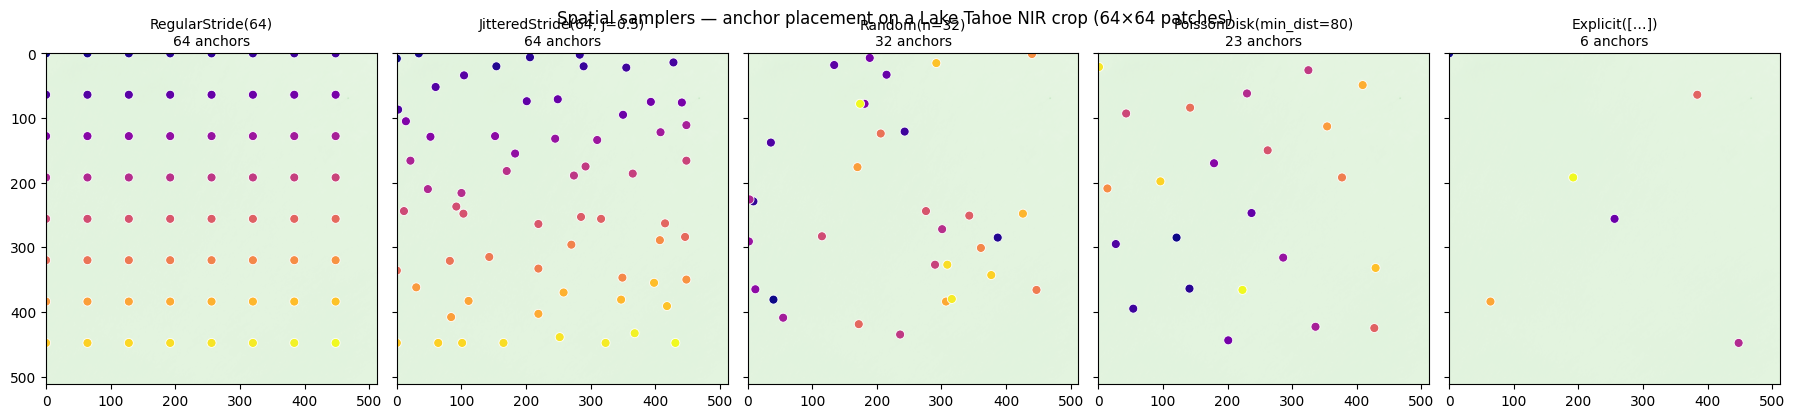

In [3]:
samplers = {
    "RegularStride(64)": SpatialRegularStride(step=64),
    "JitteredStride(64, j=0.5)": SpatialJitteredStride(step=64, jitter=0.5, seed=0),
    "Random(n=32)": SpatialRandom(n_samples=32, seed=0),
    "PoissonDisk(min_dist=80)": SpatialPoissonDisk(min_dist=80.0, seed=0),
    "Explicit([…])": SpatialExplicit(
        anchors_=[(0, 0), (256, 256), (448, 448), (64, 384), (384, 64), (192, 192)]
    ),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4.0), sharey=True)
for ax, (name, sampler) in zip(axes, samplers.items(), strict=True):
    anchors = list(sampler.anchors(field.domain, geom))
    n = len(anchors)
    ax.imshow(crop, cmap="Greens", vmin=0, vmax=0.5, alpha=0.55)
    rs, cs = zip(*anchors, strict=True) if anchors else ([], [])
    ax.scatter(
        cs, rs, c=np.arange(n), cmap="plasma", s=42, edgecolor="white", linewidth=0.6
    )
    ax.set_xlim(0, 512)
    ax.set_ylim(512, 0)  # row 0 at top
    ax.set_aspect("equal")
    ax.set_title(f"{name}\n{n} anchors", fontsize=10)
fig.suptitle(
    "Spatial samplers — anchor placement on a Lake Tahoe NIR crop (64×64 patches)"
)
plt.tight_layout()
plt.show()

### What to notice

- `RegularStride` and `JitteredStride` produce a fixed-cardinality lattice.
  Jittering shakes each anchor by a fraction of the step — useful as
  training-time augmentation (see [`../06_ml_patches_augment`](../06_ml_patches_augment.ipynb)).
- `Random` is uniform random; samples can clump. Good for cheap data
  augmentation but boundary coverage isn't guaranteed.
- `PoissonDisk` guarantees a minimum pairwise distance via Bridson's
  algorithm — well-spaced random samples with no redundancy.
- `Explicit` is the universal escape hatch — you provide the list yourself
  (e.g. station locations, event detections).

## 3. Pairwise-distance comparison

Quantify the spacing properties: histogram of nearest-neighbour
distances per sampler.

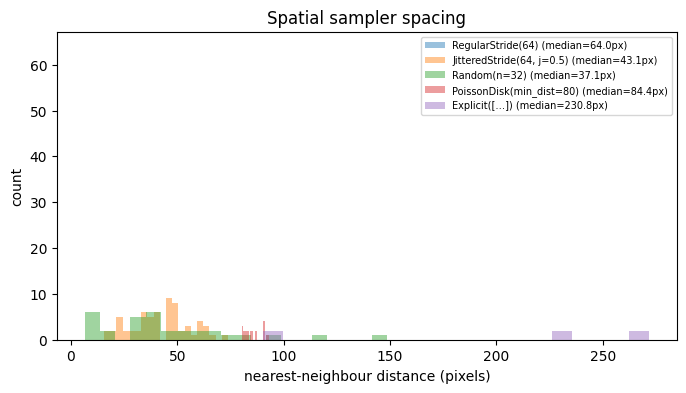

In [4]:
def nn_distances(anchors: list[tuple[int, int]]) -> np.ndarray:
    """Each anchor's distance to its nearest neighbour."""
    if len(anchors) < 2:
        return np.array([])
    pts = np.asarray(anchors, dtype=float)
    tree = cKDTree(pts)
    d, _ = tree.query(pts, k=2)
    return d[:, 1]


fig, ax = plt.subplots(figsize=(8, 4))
for name, sampler in samplers.items():
    anchors = list(sampler.anchors(field.domain, geom))
    d = nn_distances(anchors)
    if d.size:
        ax.hist(d, bins=20, alpha=0.45, label=f"{name} (median={np.median(d):.1f}px)")
ax.set_xlabel("nearest-neighbour distance (pixels)")
ax.set_ylabel("count")
ax.set_title("Spatial sampler spacing")
ax.legend(fontsize=7)
plt.show()

## 4. Temporal samplers on a time series

The temporal samplers index integer positions along a time axis. We
visualise where each places its anchors on a 100-step series — think
of these as scene-acquisition dates rather than pixel rows.

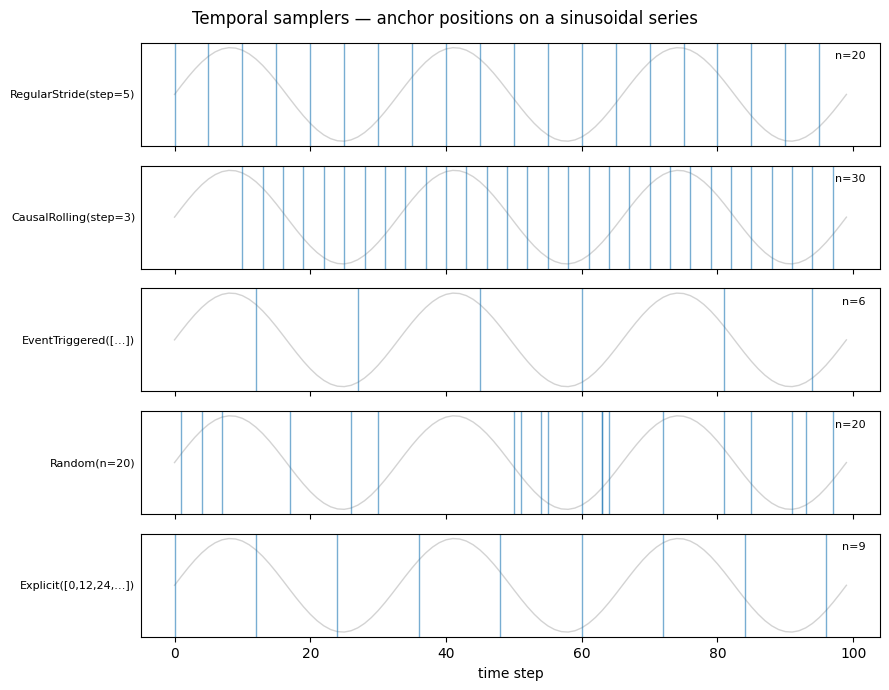

In [5]:
T = 100
series = np.sin(np.linspace(0, 6 * np.pi, T))

temporal_samplers = {
    "RegularStride(step=5)": TemporalRegularStride(step=5),
    "CausalRolling(step=3)": TemporalCausalRolling(step=3, start=10),
    "EventTriggered([…])": TemporalEventTriggered(event_times=[12, 27, 45, 60, 81, 94]),
    "Random(n=20)": TemporalRandom(n=20, seed=0),
    "Explicit([0,12,24,…])": TemporalExplicit(times=list(range(0, T, 12))),
}

fig, axes = plt.subplots(len(temporal_samplers), 1, figsize=(9, 7), sharex=True)
for ax, (name, sampler) in zip(axes, temporal_samplers.items(), strict=True):
    ax.plot(series, color="lightgray", lw=1)
    anchors = list(sampler.anchors(T))
    for a in anchors:
        ax.axvline(a, color="C0", alpha=0.6, lw=1)
    ax.set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")
    ax.set_yticks([])
    ax.text(
        0.98,
        0.85,
        f"n={len(anchors)}",
        transform=ax.transAxes,
        ha="right",
        fontsize=8,
    )
axes[-1].set_xlabel("time step")
plt.suptitle("Temporal samplers — anchor positions on a sinusoidal series")
plt.tight_layout()
plt.show()

## 5. Choosing a sampler

Rough decision table:

| Need | Sampler |
|---|---|
| Dense reconstruction (no overlap) | `RegularStride(step=size)` |
| Dense reconstruction (overlap) | `RegularStride(step<size)` + Hann/Tukey window |
| Training augmentation (regular + jitter) | `JitteredStride` |
| Training augmentation (uniform random) | `Random(n_samples=…)` |
| Well-spaced random samples | `PoissonDisk(min_dist=…)` |
| Anchors from external data (stations, events) | `Explicit` / `EventTriggered` |
| Past-only rolling window | `CausalRolling` |

Whichever you pick, the rest of the Patcher (geometry, window, aggregation)
stays unchanged — sampling decisions can be A/B-tested independently of the
operator pipeline.